# 知识点

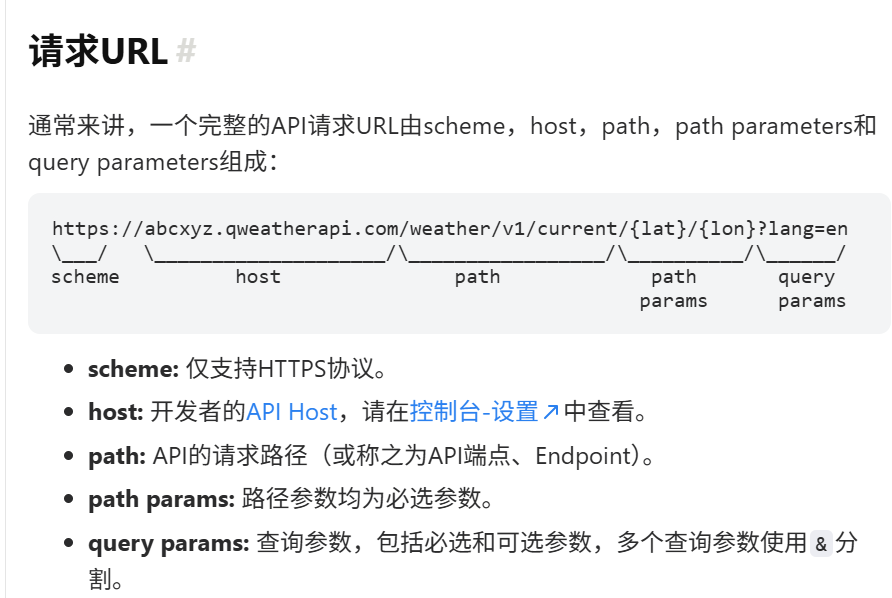

对于from langchain.agents import AgentExecutor, create_react_agent

如果你安装的是 langchain v0.x（旧版）：你的代码完美运行。

如果你安装的是 langchain v1.0 或更高版本：执行这行导入时，可能会遇到 ImportError，报错说找不到 AgentExecutor。你需要额外安装 langchain-classic 包，并修改导入路径为 from langchain_classic.agents import AgentExecutor, create_react_agent。

所以直接from langchain.agents import create_agent


In [ ]:
# 在 LangChain 1.x 中，hub 模块确实被移出了主包，导入方式发生了变化。

# pip install langsmith

from langsmith import Client

client = Client()
prompt = client.pull_prompt(
    "hwchase17/react",
    include_model=True,
    dangerously_pull_public_prompt=True  # 拉取公开 prompt 时需要此参数
)
# include_model=True 会同时拉取 prompt 关联的模型配置，
# dangerously_pull_public_prompt=True 是 
# LangChain 出于安全考虑要求显式确认拉取公开 prompt

In [ ]:
agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="You are a helpful assistant with access to tools. "
                  "Use the tools to answer the user's questions."
)

result = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "今天是几号？北京天气怎么样？如果出门步行 5km 消耗约 300 卡路里，"
             "跑步同样距离消耗大约是步行的 1.6 倍，请计算跑步消耗的卡路里。"}
        ]
    }
)
print(result["messages"][-1].content)

为什么不需要手动拉 ReAct prompt？
你之前代码里的注释写得没错：“ReAct 模式主要由 prompt 实现”。但在 LangChain 1.x 中，create_agent 底层已经内置了标准的工具调用循环（模型调用 → 执行工具 → 再次调用模型 → 直到无工具调用为止）。你只需要提供系统提示词和工具列表，ReAct 的“思考-行动”逻辑由框架自动驱动。

In [ ]:
# 普通大模型调用：
result = app.invoke(
    {
        "topic": "生成式AI对软件开发行业的影响",
        "revision_count": 0
    })

# agent调用
result = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "今天是几号？北京天气怎么样？如果出门步行 5km 消耗约 300 卡路里，"
             "跑步同样距离消耗大约是步行的 1.6 倍，请计算跑步消耗的卡路里。"}
        ]
    }
)


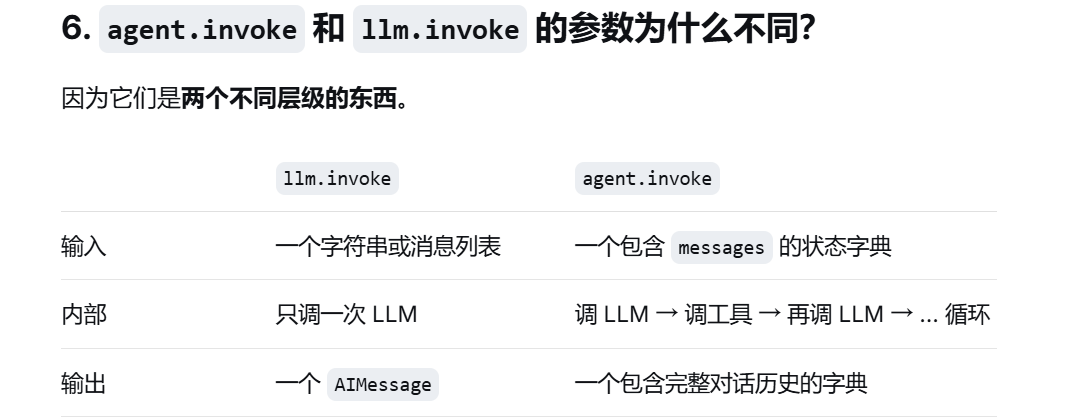

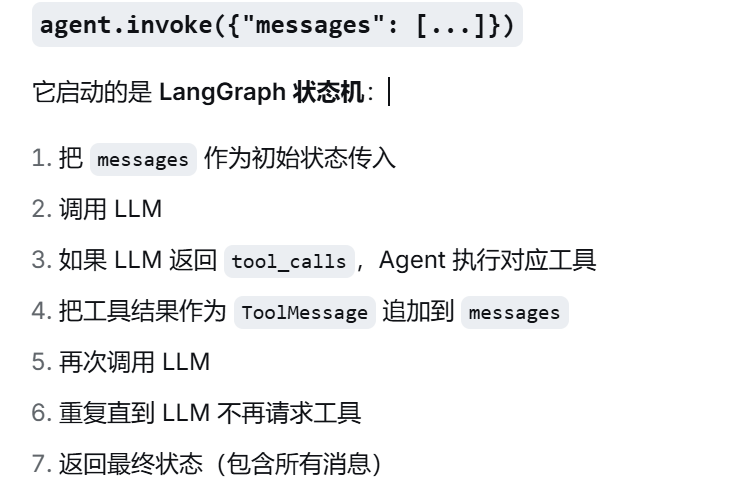